<a href="https://colab.research.google.com/github/Karthikreddy1010/Electric-poles-and-wires-detection/blob/main/Basic_Electric_utility_pole.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

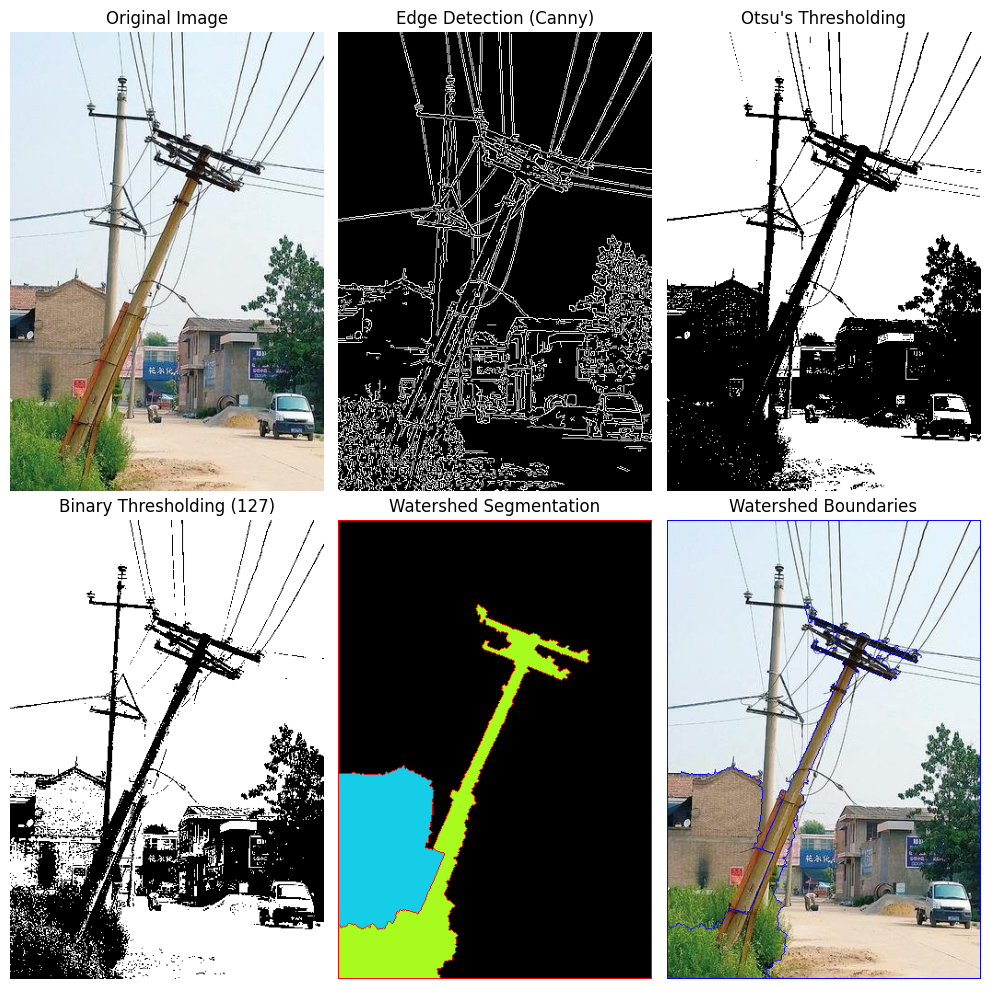

Results saved as:
- segmentation_results.png (comparison)
- edges.jpg
- otsu_threshold.jpg
- binary_threshold.jpg
- watershed.jpg (colored labels)
- watershed_overlay.jpg (boundaries on original)


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from scipy import ndimage

def process_image(image_path):
    # Read the image
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Image not found!")
        return

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Edge Detection (Canny)
    edges = cv2.Canny(gray, 100, 200)

    # Otsu's Thresholding
    _, otsu_thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Binary Thresholding
    _, binary_thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    # ===== WATERSHED SEGMENTATION =====
    # Preprocessing for watershed
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Noise removal (morphology)
    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    # Sure background area
    sure_bg = cv2.dilate(opening, kernel, iterations=3)

    # Distance transform
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_transform, 0.5*dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)

    # Unknown region
    unknown = cv2.subtract(sure_bg, sure_fg)

    # Marker labelling
    _, markers = cv2.connectedComponents(sure_fg)

    # Add one to all labels so background is 1
    markers = markers + 1

    # Mark the unknown region with 0
    markers[unknown == 255] = 0

    # Apply watershed
    markers = cv2.watershed(img, markers)

    # Create colored labels
    unique_labels = np.unique(markers)
    colors = [np.array([np.random.randint(0, 255),
                        np.random.randint(0, 255),
                        np.random.randint(0, 255)]) for _ in unique_labels]

    watershed_output = np.zeros((markers.shape[0], markers.shape[1], 3), dtype=np.uint8)
    for label in unique_labels:
        if label == -1:  # Watershed boundary
            watershed_output[markers == label] = [255, 0, 0]  # Red boundaries
        elif label == 1:  # Background
            watershed_output[markers == label] = [0, 0, 0]   # Black background
        else:
            watershed_output[markers == label] = colors[label]  # Random color for objects

    # ===== VISUALIZATION =====
    plt.figure(figsize=(10, 10))

    # Original Image
    plt.subplot(2, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    # Edge Detection
    plt.subplot(2, 3, 2)
    plt.imshow(edges, cmap='gray')
    plt.title('Edge Detection (Canny)')
    plt.axis('off')

    # Otsu's Thresholding
    plt.subplot(2, 3, 3)
    plt.imshow(otsu_thresh, cmap='gray')
    plt.title("Otsu's Thresholding")
    plt.axis('off')

    # Binary Thresholding
    plt.subplot(2, 3, 4)
    plt.imshow(binary_thresh, cmap='gray')
    plt.title('Binary Thresholding (127)')
    plt.axis('off')

    # Watershed Segmentation
    plt.subplot(2, 3, 5)
    plt.imshow(watershed_output)
    plt.title('Watershed Segmentation')
    plt.axis('off')

    # Watershed Overlay
    plt.subplot(2, 3, 6)
    overlay = img.copy()
    overlay[markers == -1] = [255, 0, 0]  # Mark boundaries in red
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title('Watershed Boundaries')
    plt.axis('off')

    plt.tight_layout()
    plt.savefig('segmentation_results.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Save individual images
    cv2.imwrite('edges.jpg', edges)
    cv2.imwrite('otsu_threshold.jpg', otsu_thresh)
    cv2.imwrite('binary_threshold.jpg', binary_thresh)
    cv2.imwrite('watershed.jpg', cv2.cvtColor(watershed_output, cv2.COLOR_RGB2BGR))
    cv2.imwrite('watershed_overlay.jpg', overlay)

    print("Results saved as:")
    print("- segmentation_results.png (comparison)")
    print("- edges.jpg")
    print("- otsu_threshold.jpg")
    print("- binary_threshold.jpg")
    print("- watershed.jpg (colored labels)")
    print("- watershed_overlay.jpg (boundaries on original)")

# Usage
process_image('pole (1).jpg')

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """(Conv2d => BN => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upscaling then double conv"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)

        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # Input is CHW
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1, bilinear=True):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)
        self.up1 = Up(1024, 512, bilinear)
        self.up2 = Up(512, 256, bilinear)
        self.up3 = Up(256, 128, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return torch.sigmoid(logits)  # For binary segmentation

In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import cv2
import numpy as np
import os
import albumentations as A # Import albumentations library

class PoleDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = os.listdir(img_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx].replace('.jpg', '_mask.png'))

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        image = image.transpose(2, 0, 1)  # HWC to CHW
        image = torch.from_numpy(image).float() / 255.0
        mask = torch.from_numpy(mask).float() / 255.0

        return image, mask.unsqueeze(0)  # Add channel dim

# Augmentations
transform = A.Compose([
    A.RandomBrightnessContrast(p=0.2),
    A.VerticalFlip(p=0.5),  # Poles are symmetric vertically
    A.Rotate(limit=10, p=0.5),  # Small rotations
    A.Resize(512, 512)
])

# Initialize
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCELoss()  # Binary Cross-Entropy

# Data
# Make sure 'data/train/images' and 'data/train/masks' directories exist and contain data
train_dataset = PoleDataset('data/train/images', 'data/train/masks', transform)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# Training loop
for epoch in range(100):
    model.train()
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

    print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

In [ ]:
class DiceBCELoss(nn.Module):
    def __init__(self, weight=1.0):
        super(DiceBCELoss, self).__init__()
        self.weight = weight

    def forward(self, inputs, targets):
        # Binary cross-entropy
        bce = F.binary_cross_entropy(inputs, targets)

        # Dice coefficient
        smooth = 1.0
        intersection = (inputs * targets).sum()
        dice = (2. * intersection + smooth) / (inputs.sum() + targets.sum() + smooth)

        return bce + self.weight * (1 - dice)

In [ ]:
def postprocess_mask(mask):
    """Clean up predicted mask for utility poles"""
    mask = (mask.squeeze() > 0.5).cpu().numpy().astype('uint8') * 255

    # Remove small noise
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    # Keep only vertical components (poles are vertical)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        x,y,w,h = cv2.boundingRect(cnt)
        aspect_ratio = float(h)/w
        if aspect_ratio < 2:  # Filter non-vertical components
            cv2.drawContours(mask, [cnt], 0, 0, -1)

    return mask

In [ ]:
def predict_single_image(model, image_path, device):
    # Load and preprocess
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (512, 512))
    image_tensor = torch.from_numpy(image.transpose(2,0,1)).float().unsqueeze(0)/255.0
    image_tensor = image_tensor.to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        mask = model(image_tensor)

    # Post-process
    final_mask = postprocess_mask(mask)

    # Visualize
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title('Input Image')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(final_mask, cmap='gray')
    plt.title('Predicted Mask')
    plt.axis('off')
    plt.show()

    return final_mask

# Usage
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet().to(device)
model.load_state_dict(torch.load('unet_poles.pth'))
mask = predict_single_image(model, 'pole (1).jpg', device)

In [ ]:
import cv2
import numpy as np
import os

class SingleImagePoleAnalyzer:
    def __init__(self):
        self.camera_height = 2.5  # GSV camera height in meters (standard)

    def extract_pole_contour(self, pole_mask):
        """Extract the largest contour from pole mask"""
        contours, _ = cv2.findContours(pole_mask.astype(np.uint8),
                                     cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            return max(contours, key=cv2.contourArea)
        return None

    def parse_gsv_metadata(self, metadata):
        """Extract camera parameters from GSV metadata"""
        return {
            'focal_length': metadata.get('focal_length', 800),  # in pixels
            'image_width': metadata.get('width', 640),
            'image_height': metadata.get('height', 480),
            'camera_pitch': metadata.get('pitch', -3.0),  # in degrees
            'camera_roll': metadata.get('roll', 0.0),    # in degrees
            'heading': metadata.get('heading', 0)      # in degrees
        }

    def extract_parameters_from_single_image(self, pole_mask, gsv_metadata):
        """Extract height and angle from single GSV image using camera geometry"""
        # Step 1: Extract camera parameters from GSV metadata
        camera_params = self.parse_gsv_metadata(gsv_metadata)

        # Step 2: Process pole mask to get precise measurements
        pole_contour = self.extract_pole_contour(pole_mask)
        if pole_contour is None:
            return None, None, None

        # Step 3: Calculate height using perspective geometry
        height = self.calculate_height_single_image(pole_contour, camera_params)

        # Step 4: Calculate leaning angle
        angle = self.calculate_angle_single_image(pole_contour, camera_params)

        # Step 5: Calculate distance to pole
        distance = self.calculate_distance_to_pole(pole_contour, camera_params)

        return float(height) if height else None, float(angle) if angle else None, float(distance) if distance else None

    def calculate_height_single_image(self, pole_contour, camera_params):
        """Calculate pole height using perspective geometry from single image"""
        # Get the bounding box of the pole
        x, y, w, h = cv2.boundingRect(pole_contour)

        # Convert camera pitch to radians
        pitch_rad = np.radians(camera_params['camera_pitch'])

        # Calculate the base and top of the pole in image coordinates
        pole_base_y = y + h  # Bottom of bounding box (touching ground)
        pole_top_y = y       # Top of bounding box

        # Image center (principal point)
        center_y = camera_params['image_height'] / 2

        # Focal length
        f = camera_params['focal_length']

        # Calculate angles from camera to base and top of pole
        theta_base = np.arctan2(pole_base_y - center_y, f) - pitch_rad
        theta_top = np.arctan2(pole_top_y - center_y, f) - pitch_rad

        # Calculate height using trigonometric relationships
        tan_base = np.tan(theta_base)
        tan_top = np.tan(theta_top)

        if abs(tan_base) < 1e-6:  # Avoid division by zero
            height = self.camera_height * (tan_top - tan_base)
        else:
            height = self.camera_height * (tan_top - tan_base) / (1 + tan_base * tan_top)

        return abs(height)  # Height should be positive

    def calculate_distance_to_pole(self, pole_contour, camera_params):
        """Calculate distance from camera to pole base"""
        x, y, w, h = cv2.boundingRect(pole_contour)
        pole_base_y = y + h

        pitch_rad = np.radians(camera_params['camera_pitch'])
        f = camera_params['focal_length']
        center_y = camera_params['image_height'] / 2

        # Angle to pole base
        theta_base = np.arctan2(pole_base_y - center_y, f) - pitch_rad

        # Distance = camera_height / tan(θ_base)
        if abs(theta_base) > 1e-6:
            distance = self.camera_height / np.tan(theta_base)
        else:
            distance = 100  # Large distance for poles near horizon

        return abs(distance)

    def calculate_angle_single_image(self, pole_contour, camera_params):
        """Calculate pole leaning angle with perspective correction"""
        # Fit a line to the pole contour
        if len(pole_contour) < 5:
            return 0.0

        [vx, vy, x, y] = cv2.fitLine(pole_contour, cv2.DIST_L2, 0, 0.01, 0.01)

        # Calculate the angle in image coordinates
        line_angle_image = np.degrees(np.arctan2(vy, vx[0])) - 90

        # Correct for camera roll
        line_angle_corrected = line_angle_image - camera_params['camera_roll']

        # Apply perspective correction based on pole position
        perspective_correction = self.calculate_perspective_correction(
            pole_contour, camera_params
        )

        final_angle = line_angle_corrected + perspective_correction

        # Constrain to reasonable values (-15 to +15 degrees typically)
        return float(np.clip(final_angle, -15, 15))

    def calculate_perspective_correction(self, pole_contour, camera_params):
        """Calculate perspective distortion correction based on pole position in image"""
        # Get pole position in image
        x, y, w, h = cv2.boundingRect(pole_contour)
        pole_center_x = x + w/2

        # Normalize position (-1 to +1 from center)
        normalized_x = (pole_center_x - camera_params['image_width']/2) / (camera_params['image_width']/2)

        # Perspective distortion increases towards image edges
        perspective_factor = 0.5  # Degrees of correction at image edge

        return normalized_x * perspective_factor

    def fallback_height_estimation(self, pole_mask, camera_params):
        """Fallback method using empirical relationships"""
        # Calculate pixel height of pole
        contour = self.extract_pole_contour(pole_mask)
        if contour is None:
            return None

        x, y, w, h = cv2.boundingRect(contour)

        # Empirical relationship: typical poles are 8-12 meters
        normalized_height = h / camera_params['image_height']

        # Base height assumption (can be calibrated)
        base_height = 10.0  # meters

        # Adjust based on position in image (poles higher in image are farther)
        position_factor = 1.0 + (y / camera_params['image_height']) * 0.5

        estimated_height = base_height * normalized_height * position_factor
        return float(estimated_height)

    def calculate_measurement_confidence(self, pole_mask, height, angle, camera_params):
        """Calculate confidence score for measurements (0-1 scale)"""
        confidence_factors = []

        # Factor 1: Pole mask quality
        contour = self.extract_pole_contour(pole_mask)
        if contour is not None:
            area = cv2.contourArea(contour)
            x, y, w, h = cv2.boundingRect(contour)
            extent = area / (w * h) if w * h > 0 else 0
            confidence_factors.append(extent)  # Better fit = higher confidence

        # Factor 2: Pole height reasonableness
        if height is not None:
            height_confidence = 1.0 - abs(height - 10.0) / 10.0  # Center around typical 10m
            height_confidence = np.clip(height_confidence, 0.1, 1.0)
            confidence_factors.append(float(height_confidence))

        # Factor 3: Image position (center is better)
        if contour is not None:
            x, y, w, h = cv2.boundingRect(contour)
            center_x = x + w/2
            center_y = y + h/2

            dist_from_center = np.sqrt(
                (center_x - camera_params['image_width']/2)**2 +
                (center_y - camera_params['image_height']/2)**2
            )
            max_dist = np.sqrt((camera_params['image_width']/2)**2 +
                              (camera_params['image_height']/2)**2)
            position_confidence = 1.0 - (dist_from_center / max_dist) * 0.5
            confidence_factors.append(float(position_confidence))

        return float(np.mean(confidence_factors)) if confidence_factors else 0.1

    def robust_parameter_extraction(self, pole_masks, gsv_metadata):
        """Robust extraction with multiple fallback methods and confidence scoring"""
        results = []

        for i, pole_mask in enumerate(pole_masks):
            try:
                # Method 1: Primary geometric calculation
                height, angle, distance = self.extract_parameters_from_single_image(
                    pole_mask, gsv_metadata
                )

                # Method 2: Fallback - Bounding box proportion method
                if height is None or height <= 0:
                    height = self.fallback_height_estimation(pole_mask, gsv_metadata)

                # Calculate confidence scores
                confidence = self.calculate_measurement_confidence(
                    pole_mask, height, angle, gsv_metadata
                )

                results.append({
                    'pole_id': i,
                    'height': height,
                    'angle': angle,
                    'distance': distance,
                    'confidence': confidence,
                    'method_used': 'geometric' if height else 'fallback'
                })

            except Exception as e:
                print(f"Error processing pole {i}: {e}")
                results.append({
                    'pole_id': i,
                    'height': None,
                    'angle': None,
                    'distance': None,
                    'confidence': 0.0,
                    'error': str(e)
                })

        return results

def create_pole_mask_manual(image_path):
    """
    Create a manual pole mask for testing with your image
    This is a temporary solution until you have your segmentation model ready
    """
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not load image {image_path}")
        return None, None

    height, width = image.shape[:2]

    # Create a mask by detecting edges and finding pole-like structures
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply edge detection
    edges = cv2.Canny(gray, 50, 150)

    # Find contours
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Filter contours that look like poles (tall and thin)
    pole_contours = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if h > 100 and w < 50 and h/w > 3:  # Tall and thin
            pole_contours.append(contour)

    # Create mask from pole contours
    pole_mask = np.zeros((height, width), dtype=np.uint8)
    if pole_contours:
        # Use the largest pole-like contour
        largest_contour = max(pole_contours, key=cv2.contourArea)
        cv2.drawContours(pole_mask, [largest_contour], -1, 255, -1)

    return image, [pole_mask]

def visualize_results(image, pole_masks, results):
    """Visualize the poles and their measurements on the image"""
    output_image = image.copy()

    for i, (pole_mask, result) in enumerate(zip(pole_masks, results)):
        # Find contour of pole
        contours, _ = cv2.findContours(pole_mask.astype(np.uint8),
                                     cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            # Draw contour
            cv2.drawContours(output_image, contours, -1, (0, 255, 0), 2)

            # Add text with measurements
            x, y, w, h = cv2.boundingRect(contours[0])
            if result['height'] is not None:
                text = f"Pole {i}: H={result['height']:.1f}m A={result['angle']:.1f}°"
                cv2.putText(output_image, text, (x, y-10),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    return output_image

def main():
    # Initialize analyzer
    analyzer = SingleImagePoleAnalyzer()

    # Use your actual image
    image_path = "pole (1).jpg"

    if not os.path.exists(image_path):
        print(f"Error: Image file '{image_path}' not found!")
        print("Please make sure the image is in the same directory as this script.")
        return

    print("=== Google Street View Pole Parameter Extraction ===")
    print(f"Processing image: {image_path}")

    # Create pole mask from your image
    image, pole_masks = create_pole_mask_manual(image_path)

    if image is None:
        return

    # GSV metadata (you may need to adjust these based on your actual GSV metadata)
    gsv_metadata = {
        'focal_length': 800,      # pixels - typical for GSV
        'image_width': image.shape[1],
        'image_height': image.shape[0],
        'camera_pitch': -3.0,     # degrees (negative = looking slightly down)
        'camera_roll': 0.0,       # degrees
        'heading': 0.0           # degrees
    }

    print(f"Image dimensions: {image.shape[1]} x {image.shape[0]}")
    print(f"Detected {len(pole_masks)} poles")

    # Extract parameters
    results = analyzer.robust_parameter_extraction(pole_masks, gsv_metadata)

    # Display results
    print("\n=== EXTRACTION RESULTS ===")
    for result in results:
        if result['height'] is not None:
            print(f"Pole {result['pole_id']}:")
            print(f"  Height: {result['height']:.2f} meters")
            print(f"  Angle: {result['angle']:.1f} degrees")
            print(f"  Distance: {result['distance']:.1f} meters")
            print(f"  Confidence: {result['confidence']:.2f}")
            print(f"  Method: {result['method_used']}")
        else:
            print(f"Pole {result['pole_id']}: Failed to extract parameters")
        print()

    # Visualize results
    output_image = visualize_results(image, pole_masks, results)

    # Save and display
    output_path = 'pole_analysis_results.jpg'
    cv2.imwrite(output_path, output_image)
    print(f"Results visualization saved as '{output_path}'")

    # Display image
    try:
        # Resize if too large for display
        h, w = output_image.shape[:2]
        if w > 1200:
            scale = 1200 / w
            output_image = cv2.resize(output_image, (int(w*scale), int(h*scale)))

        cv2.imshow('Pole Analysis Results', output_image)
        print("Press any key to close the image window...")
        cv2.waitKey(0)
        cv2.destroyAllWindows()
    except Exception as e:
        print(f"Cannot display image: {e}")
        print("Check the saved file 'pole_analysis_results.jpg' instead")

    return results

if __name__ == "__main__":
    results = main()